In [2]:
# START OF BASE DATA IMPORTS
from google.colab import files

print("Please upload your CSV file.")
uploaded = files.upload()

file_path_1 = next(iter(uploaded))

Please upload your CSV file.


Saving visa_issuance.csv to visa_issuance (1).csv


In [3]:
import pandas as pd

visa_df = pd.read_csv("visa_issuance.csv")

visa_df

,Country,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,3063,2723,1902,1552,1554,856,535,0,0,0
1,Albania,6600,8524,10001,12153,11489,6982,5524,14423,25483,25731
2,Algeria,11855,13704,11353,12888,12272,5137,691,11613,19240,19142
3,Angola,11330,6859,7670,7538,4904,1866,1394,3873,5446,5812
4,Argentina,249293,303897,360891,334430,222043,90187,39256,219375,288110,289971
...,...,...,...,...,...,...,...,...,...,...,...
163,Venezuela,239772,151014,47942,21290,4614,0,0,0,0,0
164,Vietnam,101221,104830,121118,123416,131093,64050,35212,92912,127380,144974
165,Yemen,656,0,0,0,0,0,0,0,0,0
166,Zambia,3752,4021,4365,4747,3736,1350,1049,6111,8081,3978


In [4]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [5]:
dataset_path = kagglehub.dataset_download('justin2028/us-immigration-statistics-1980-2021')

Using Colab cache for faster access to the 'us-immigration-statistics-1980-2021' dataset.


In [6]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [10]:
files = os.listdir(dataset_path)
print(files)

immigrations_df = pd.read_csv(os.path.join(dataset_path, files[0]))

['US Immigration Statistics (Ver 1.14.26).csv']


In [13]:
# Convert into a readable number data
immigrations_df = immigrations_df[immigrations_df['Year'] >= 2001]
immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'] = immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Removals'] = immigrations_df['Noncitizen Removals'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Apprehensions'] = immigrations_df['Noncitizen Apprehensions'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Refugee Arrivals'] = immigrations_df['Refugee Arrivals'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Returns'] = immigrations_df['Noncitizen Returns'].astype(str).str.replace(',', '', regex=False).astype(int)

/tmp/ipykernel_85129/3671655085.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'] = immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'].astype(str).str.replace(',', '', regex=False).astype(int)
/tmp/ipykernel_85129/3671655085.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  immigrations_df['Noncitizen Removals'] = immigrations_df['Noncitizen Removals'].astype(str).str.replace(',', '', regex=False).astype(int)


In [14]:
dataset_path = kagglehub.dataset_download('haejeg1/m-data')

In [15]:
files = os.listdir(dataset_path)
print(files)

immigrations_10_years_df = pd.read_csv(os.path.join(dataset_path, files[0]))
removals_df = pd.read_csv(os.path.join(dataset_path, files[1]))
net_migrations_df = pd.read_csv(os.path.join(dataset_path, files[2]))
arrests_df = pd.read_csv(os.path.join(dataset_path, files[3]))
# END OF BASE DATA IMPORTS

['immigrations.csv', 'removals.csv', 'net_migrations.csv', 'arrests.csv']


In [16]:
immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'] = immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'].astype(float)
immigrations_df = immigrations_df.dropna(subset=['Year', 'Immigrants Obtaining Lawful Permanent Resident Status'])
immigrations_df['Year'] = immigrations_df['Year'].astype(int)
immigrations_df = immigrations_df[immigrations_df['Year'].astype(int) >= 2001]

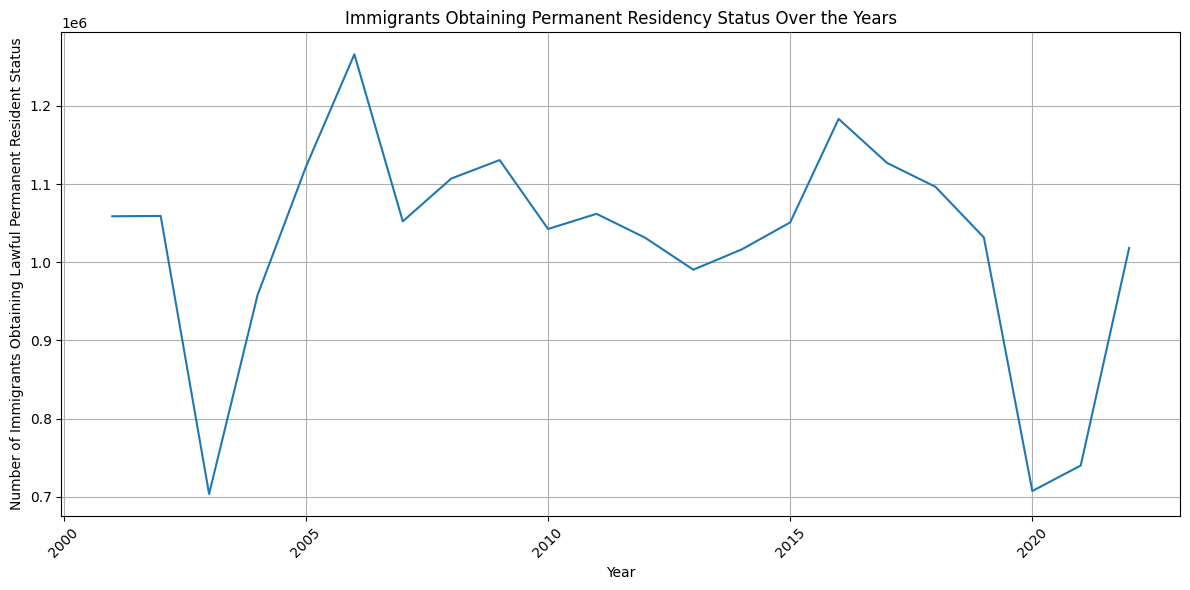

In [17]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Immigrants Obtaining Lawful Permanent Resident Status', data=immigrations_df)
plt.title('Immigrants Obtaining Permanent Residency Status Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants Obtaining Lawful Permanent Resident Status')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2001 - 2005 security tightening after 9/11
# 2020 covid
# let's try to figure the rest out.

In [18]:
# Let's see which years have been the most leniant towards overall
# visa grants.

year_columns = [col for col in visa_df.columns if col.isdigit() and len(col) == 4]

total_visas_by_year = visa_df[year_columns].sum().reset_index()
total_visas_by_year.columns = ['Year', 'Total Visas']

display(total_visas_by_year)

,Year,Total Visas
0,2015,10872841
1,2016,10362160
2,2017,9662395
3,2018,9009149
4,2019,8668140
5,2020,3966667
6,2021,2837352
7,2022,6807313
8,2023,10363119
9,2024,10812587


In [19]:
total_visas_by_year['Percentage Change'] = total_visas_by_year['Total Visas'].pct_change() * 100

display(total_visas_by_year)

,Year,Total Visas,Percentage Change
0,2015,10872841,NaN
1,2016,10362160,-4.696850
2,2017,9662395,-6.753080
3,2018,9009149,-6.760705
4,2019,8668140,-3.785141
5,2020,3966667,-54.238545
6,2021,2837352,-28.470124
7,2022,6807313,139.917818
8,2023,10363119,52.235089
9,2024,10812587,4.337188


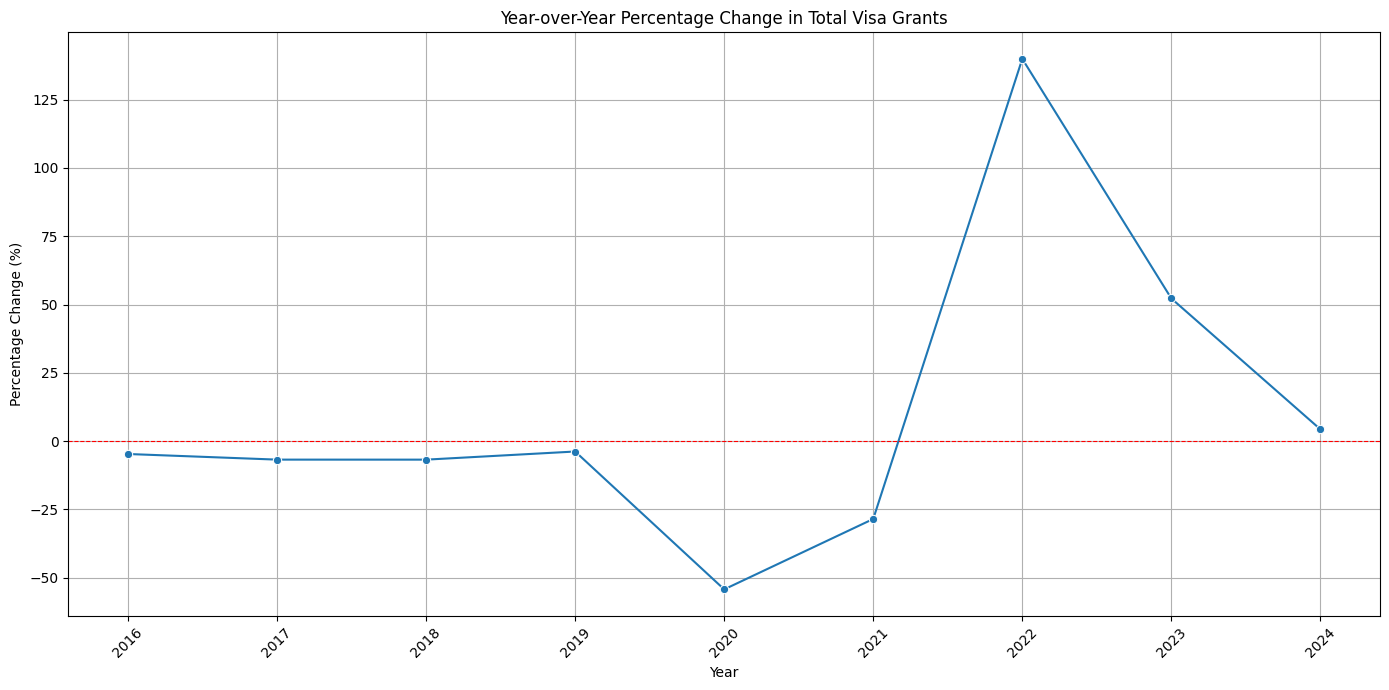

In [20]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Year', y='Percentage Change', data=total_visas_by_year, marker='o')
plt.title('Year-over-Year Percentage Change in Total Visa Grants')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a line at 0% change
plt.tight_layout()
plt.show()

# Wow 2022 was a big spike. What happened here?

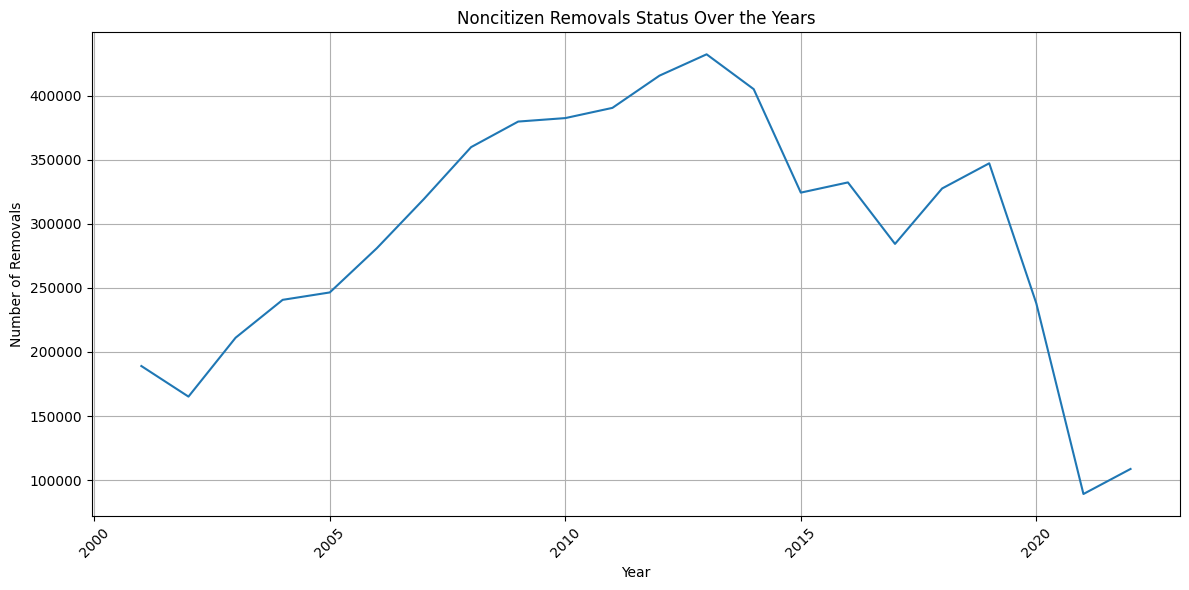

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Noncitizen Removals', data=immigrations_df)
plt.title('Noncitizen Removals Status Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Removals')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### To potentially do next?!
# Yeah okay I'm so tired but we could probably relate to each most popular removed countries from the ice data
# and just go ahead and see how each policy impacts each ethnic group

In [ ]:
immigrations_df

,Unnamed: 0,Year,Immigrants Obtaining Lawful Permanent Resident Status,Refugee Arrivals,Noncitizen Apprehensions,Noncitizen Removals,Noncitizen Returns
0,32,2012,"1,031,631","58,179","795,735",415579,"231,105"
1,33,2013,"990,553","69,909","786,223",432201,"178,973"
2,34,2014,"1,016,518","69,975","805,334",405026,"163,836"
3,35,2015,"1,051,031","69,920","596,560",324303,"129,636"
4,36,2016,"1,183,505","84,989","683,782",332263,"106,479"
5,37,2017,"1,127,167","53,691","607,677",284298,"100,454"
6,38,2018,"1,096,611","22,405","739,486",327554,"159,960"
7,39,2019,"1,031,765","29,916","1,175,841",347183,"171,125"
8,40,2020,"707,362","11,840","609,265",237861,"167,453"
9,41,2021,"740,002","11,454","1,865,379",89191,"178,227"
